# CNN vs CNN-ViT Hybrid Architectures for Satellite Crop Classification

## Notebook 1: Data Pipeline

---

### Table of Contents

- [1. Project Overview](#1-project-overview)
  - [1.1 Motivation & Industry Context](#11-motivation--industry-context)
  - [1.2 Experimental Framing](#12-experimental-framing)
- [2. Setup & Environment](#2-setup--environment)
- [3. Dataset Description](#3-dataset-description)
- [4. Task Definition — Binary Agricultural Classification](#4-task-definition-—-binary-agricultural-classification)
  - [4.1 Selected Classes](#41-selected-classes)
  - [4.2 Balanced Dataset Construction](#42-balanced-dataset-construction)
  - [4.3 Visual Inspection](#43-visual-inspection)
- [5. Train / Validation Split](#5-train--validation-split)
- [6. Dataset Pipelines](#6-dataset-pipelines)
  - [6.1 Keras Pipeline](#61-keras-pipeline)
  - [6.2 PyTorch Pipeline](#62-pytorch-pipeline)
- [7. Framework Comparison](#7-framework-comparison)
  - [7.1 Pipeline Comparison Table](#71-pipeline-comparison-table)
  - [7.2 Visual Comparison of Augmented Samples](#72-visual-comparison-of-augmented-samples)
- [8. Summary](#8-summary)
- [Author](#author)
- [Version History](#version-history)

---

## 1. Project Overview

### 1.1 Motivation & Industry Context

Satellite imagery is increasingly leveraged across multiple sectors to extract actionable insights from land surfaces. Key applications include:

* **Precision agriculture:** optimizing planting and harvesting strategies based on accurate land use.
* **Crop monitoring and yield forecasting:** predicting agricultural output using high-resolution temporal imagery.
* **Climate impact assessment:** detecting land-use changes that affect carbon balance and environmental sustainability.
* **Land-use policy enforcement:** monitoring compliance with agricultural zoning and land management regulations.
* **Environmental sustainability tracking:** assessing soil health, forest cover, and crop rotation over time.

Within these applications, **accurate classification of agricultural land types**—distinguishing between annual and permanent crops—is critical. It enables:

* Subsidy compliance verification
* Crop rotation planning
* Long-term soil and land management strategies

In this context, I investigate a focused but realistic problem:

> Can hybrid CNN–Transformer (CNN-ViT) models deliver measurable improvements over classical CNNs in agricultural satellite classification?

Rather than limiting the comparison to a single framework, an additional layer is introduced:

> Perform cross-framework evaluations, by comparing CNN vs CNN-ViT in both Keras (TensorFlow) and PyTorch ecosystems.

This approach allows to systematically evaluate:

* **Architectural inductive bias:** local feature learning of CNNs vs global context modeling of CNN-ViT.
* **Framework behavior:** subtle differences in preprocessing, augmentation, and tensor representation between Keras (TensorFlow) and PyTorch.
* **Reproducibility:** ensuring that results are consistent across frameworks.
* **Pipeline equivalence and fairness:** controlling for differences in data handling and augmentation strategies.

### 1.2 Experimental Framing

This project is structured into **four sequential notebooks**, each building on the artifacts and insights of the previous:

1. **Data Pipeline (this notebook):** dataset exploration, binary task definition, balanced dataset creation, stratified splitting, augmentation, and reproducible pipeline setup.
2. **CNN Baseline Models (Keras + PyTorch):** implementation and training of classical CNN architectures.
3. **CNN-ViT Hybrid Models (Keras + PyTorch):** implementation and training of CNN–Transformer hybrid architectures.
4. **Overall Evaluation & Comparative Analysis:** cross-framework comparison, metric evaluation, and insights on architecture performance.

This notebook establishes the **foundational dataset artifacts**:

* Exploratory analysis of raw EuroSAT data,
* Selection and balancing of `AnnualCrop` and `PermanentCrop` images,
* Stratified train/validation splitting for consistency across frameworks,
* Framework-specific pipelines with comparable augmentation strategies,
* Reproducibility controls via fixed seeds and modular functions.

All subsequent notebooks rely on the outputs of this notebook, ensuring that architectural and framework comparisons are performed on identical data partitions and under consistent preprocessing conditions.

## 2. Setup & Environment

Before processing the dataset, the environment is set up to ensure clean logging, reproducibility, and modular code access.

* **Suppress unnecessary TensorFlow warnings** to reduce notebook clutter.
* **Import required libraries and modules**, including my custom pipeline functions (`data.py` and `data_pipeline_viz.py`).
* **Define the base dataset directory** and **global random seed** (`SEED = 7331`) to guarantee reproducibility of splits, shuffling, and augmentations across frameworks.
* **Add project modules to the system path** for seamless import.

The code below performs these steps and establishes a reproducible environment for all subsequent data processing and pipeline creation:

In [1]:
#Supressing Unnecessary TensorFlow Warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import warnings
warnings.filterwarnings("ignore")

# Defining the seed and directory
import sys
sys.path.append("/kaggle/input/datasets/filipebraiman/cnn-vit-src-modules/src") # Kggle path

from data import *
from data_pipeline_viz import *
import pandas as pd

SEED = 7331
BASE_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT" # Kggle path

# Global seed for reproucibility
set_global_seed(SEED)

E0000 00:00:1772231970.558013      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772231970.624319      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772231971.192717      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772231971.192779      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772231971.192783      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772231971.192786      17 computation_placer.cc:177] computation placer already registered. Please check linka

With this setup, all data handling, augmentations, and train/validation splits are consistent and deterministic, providing a solid foundation for fair comparisons between Keras and PyTorch pipelines.

## 3. Dataset Description

For this project, the **[EuroSAT Dataset](https://zenodo.org/records/7711810)**, which contains high-resolution RGB images captured by Sentinel-2 satellites, is used.

#### Key Properties

* **Total images:** 27,000
* **Image resolution:** 64×64 pixels
* **Classes:** 10 land-use categories
* **Coverage:** agricultural, urban, industrial, and water areas

The raw classes and their respective sample counts are:

| Class                | Images |
| -------------------- | ------ |
| AnnualCrop           | 3000   |
| PermanentCrop        | 2500   |
| Forest               | 3000   |
| HerbaceousVegetation | 3000   |
| Highway              | 2500   |
| Industrial           | 2500   |
| Pasture              | 2000   |
| Residential          | 3000   |
| River                | 2500   |
| SeaLake              | 3000   |

I verified the dataset structure by listing all subdirectories in the base dataset folder. This confirms that the data is organized by class, and allows me to count the number of images per class to plan the subsequent balanced dataset creation.

In [2]:
print("Raw dataset classes found in directory:\n")

raw_classes = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
])

for cls in raw_classes:
    n_images = len(os.listdir(os.path.join(BASE_DIR, cls)))
    print(f"{cls:<20} -> {n_images} images")

Raw dataset classes found in directory:

AnnualCrop           -> 3000 images
Forest               -> 3000 images
HerbaceousVegetation -> 3000 images
Highway              -> 2500 images
Industrial           -> 2500 images
Pasture              -> 2000 images
PermanentCrop        -> 2500 images
Residential          -> 3000 images
River                -> 2500 images
SeaLake              -> 3000 images


#### How This Data Is Handled

* Exclusive focus on the **AnnualCrop** and **PermanentCrop** classes, since the goal is a binary classification task.
* The dataset structure makes it straightforward to filter and load the relevant images using the custom pipeline functions.
* Observing the raw class counts also informs how many samples to use per class to construct a **balanced dataset**, ensuring fair training and evaluation for both Keras and PyTorch models.

## 4. Task Definition — Binary Agricultural Classification



### 4.1 Selected Classes
The focus of this project is a **binary classification task** between two agricultural land types: **AnnualCrop** and **PermanentCrop**.
These two classes are selected deliberately because:

* Both are agricultural and share structured vegetation patterns,
* They are not trivially separable, requiring models to capture subtle differences,
* They differ in lifecycle and spatial texture, providing a meaningful signal for testing architectural inductive biases.

This makes the task:

* Subtle and texture-dependent,
* Suitable for evaluating local feature extraction (CNNs) versus global context modeling (CNN-ViT).

The labels are assigned as following:
> `AnnualCrop → 0` and `PermanentCrop → 1`

In [3]:
# Defining classes and spliting the data
class_map = {
    "AnnualCrop": 0,
    "PermanentCrop": 1
}

### 4.2 Balanced Dataset Construction

To ensure fair evaluation and unbiased metrics, a balanced binary dataset is constructed:

* **Samples per class:** 2500
* **Total samples:** 5000

Balancing the dataset is important to:

* Prevent skewed decision boundaries
* Ensure meaningful comparison of metrics such as accuracy and AUC
* Provide equivalent training signal for both frameworks

The resulting class distribution is:

| Label | Class         | Samples |
| ----- | ------------- | ------- |
| 0     | AnnualCrop    | 2500    |
| 1     | PermanentCrop | 2500    |

> The custom function `build_balanced_binary_dataset` is used to load the selected classes and enforce equal sample counts per class. This ensures that both Keras and PyTorch pipelines operate on the same dataset.

In [4]:
files, labels = build_balanced_binary_dataset(
    BASE_DIR,
    class_map,
    samples_per_class=2500,
    seed=SEED
)

df = pd.DataFrame({
    "file": files,
    "label": labels
})

print("Total samples:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Total samples: 5000

Class distribution:
label
0    2500
1    2500
Name: count, dtype: int64


### 4.3 Visual Inspection

To better understand the data, I visualize sample images from each class. Observations include:

* Strong visual similarity between classes,
* Comparable color palettes and repetitive field structures,
* Subtle texture variations that differentiate annual from permanent crops.


This visual inspection also serves as an informal sanity check to confirm correct labeling and dataset integrity before proceeding to train/validation splitting and pipeline construction.

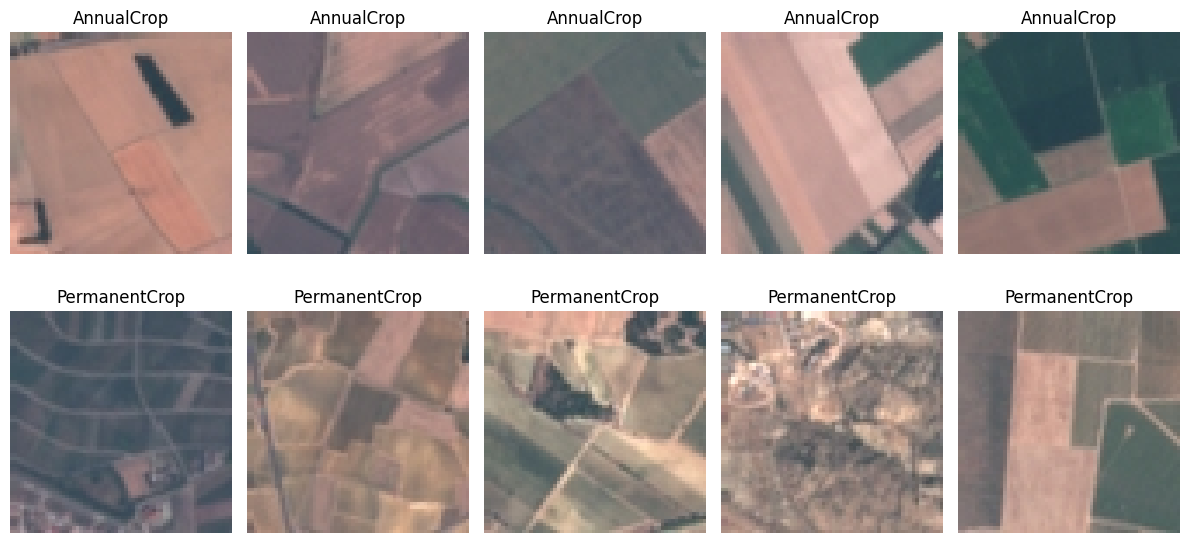

In [5]:
show_samples_per_class(files, labels, class_map, samples_per_class=5, seed=SEED)

### 5. Train / Validation Split

To prepare the dataset for training and evaluation, a stratified 80/20 split is applied:

* **Training set:** 4000 images (2000 per class)
* **Validation set:** 1000 images (500 per class)

| Split | AnnualCrop | PermanentCrop | Total |
| ----- | ---------- | ------------- | ----- |
| Train | 2000       | 2000          | 4000  |
| Val   | 500        | 500           | 1000  |

#### Why Stratification?

* Preserves the **class proportions** in both training and validation sets
* Prevents **evaluation bias** due to class imbalance
* Ensures **comparable learning dynamics** across frameworks (Keras and PyTorch)

> The `build_stratified_split` function is used to generate the train and validation partitions, maintaining deterministic results with a fixed seed (`SEED = 7331`).

In [6]:
#spliting the data

train_files, val_files, train_labels, val_labels = build_stratified_split(
    files,
    labels,
    val_split=0.2,
    seed=SEED
)

print("Train size:", len(train_files))
print("Val size:", len(val_files))

print("\nTrain distribution:")
print(pd.Series(train_labels).value_counts())

print("\nVal distribution:")
print(pd.Series(val_labels).value_counts())

Train size: 4000
Val size: 1000

Train distribution:
1    2000
0    2000
Name: count, dtype: int64

Val distribution:
1    500
0    500
Name: count, dtype: int64


## 6. Dataset Pipelines

### 6.1 Keras Pipeline

* **Tensor format:** `(Batch, Height, Width, Channels)`
* **Image size:** 64×64
* **Batch size:** 128
* **Dtype:** `float32`

**Data augmentation strategy:**

* Random horizontal flip
* Random rotation (±20%)
* Random translation (10%)
* Random zoom
* Random contrast adjustment

**Purpose:**

* Improve model generalization
* Simulate spatial variability in satellite imagery
* Reduce overfitting to small local patterns

> The Keras dataset is built using the `build_keras_datasets` function, which applies augmentation only to the training set and prefetches batches for efficient GPU usage.

In [7]:
# Keras Pipeline
train_ds_keras, val_ds_keras = build_keras_datasets(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=(64, 64),
    batch_size=128,
    seed=SEED
)

for images, labels in train_ds_keras.take(1):
    print("Keras batch image shape:", images.shape)
    print("Keras batch label shape:", labels.shape)
    print("Keras dtype:", images.dtype)

Keras batch image shape: (128, 64, 64, 3)
Keras batch label shape: (128,)
Keras dtype: <dtype: 'float32'>


### 6.2 PyTorch Pipeline

* **Tensor format:** `(Batch, Channels, Height, Width)`
* **Image size:** 64×64
* **Batch size:** 128
* **Dtype:** `float32`

**Data augmentation strategy:**

* Reflection padding
* Resize to target image size
* Random horizontal flip (p=0.5)
* Random rotation (up to 72°)
* Random affine transformations (translation + scaling)
* Contrast jitter
* Conversion to tensors

**Purpose:**

* Similar to Keras: increase generalization and simulate spatial variability
* Slight differences due to framework-specific APIs are controlled to maintain **comparable learning signals**

> The PyTorch dataset is built using a custom `EuroSATDataset` class and the `build_torch_dataloaders` function, applying augmentation only to the training set and using deterministic seeds to ensure reproducibility.

In [8]:
# Torch Pipeline
train_loader, val_loader = build_torch_dataloaders(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=(64, 64),
    batch_size=128,
    seed=SEED
)

images, labels = next(iter(train_loader))

print("Torch batch image shape:", images.shape)
print("Torch batch label shape:", labels.shape)
print("Torch dtype:", images.dtype)

Torch batch image shape: torch.Size([128, 3, 64, 64])
Torch batch label shape: torch.Size([128])
Torch dtype: torch.float32


#### Key Notes on Pipeline Design

* Keras uses a channel-last format `(B, H, W, C)`, while PyTorch uses channel-first `(B, C, H, W)`
* Augmentation strategies are equivalent in intent (rotation, translation, flip, contrast), though exact magnitudes or padding may differ
* Both pipelines ensure balanced batches, deterministic shuffling, and reproducibility with fixed seeds

These pipelines establish a consistent and fair foundation for model training, enabling meaningful comparisons between CNN and CNN-ViT architectures across frameworks.

## 7. Framework Comparison

This section highlights key differences and equivalences between Keras and PyTorch pipelines in a single, unified view.

### 7.1 Pipeline Comparison Table

This table provides a concise overview of pipeline design, including tensor conventions, augmentation strategies, and batch specifications. It serves as a reference to ensure architectural comparisons are fair and consistent across frameworks.

| Feature / Operation   | Keras Pipeline                   | PyTorch Pipeline                 |
| --------------------- | -------------------------------- | -------------------------------- |
| Tensor shape / format | (Batch, Height, Width, Channels) | (Batch, Channels, Height, Width) |
| Image size            | 64 × 64                          | 64 × 64                          |
| Batch size            | 128                              | 128                              |
| Channel order         | Channels Last                    | Channels First                   |
| Label type            | int32                            | long                             |
| Horizontal flip       | 50%                              | 50%                              |
| Rotation              | ±11°                             | ±72°                             |
| Translation           | ±10%                             | ±10% + scaling                   |
| Zoom / Scale          | ±20%                             | ±20%                             |
| Contrast adjustment   | ±20%                             | ±20%                             |
| Padding               | None                             | 10px reflection                  |
| Dtype                 | float32                          | float32                          |

### 7.2 Visual Comparison of Augmented Samples

Next, I visualize augmented samples from both pipelines side by side to confirm comparable transformations.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13169137..1.0714751].


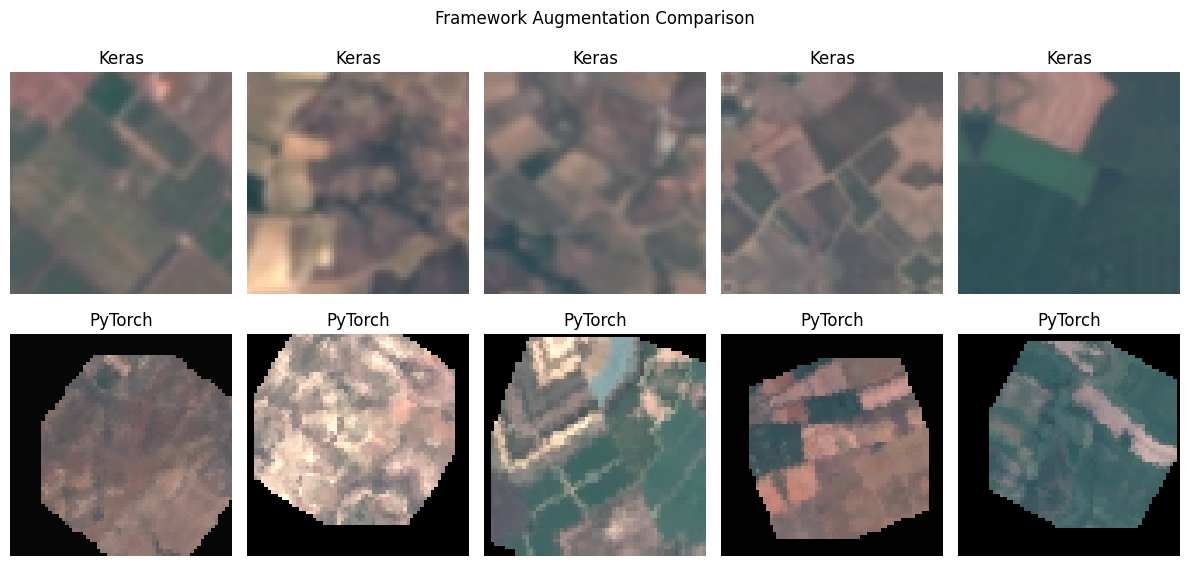

Keras batch shape : (128, 64, 64, 3)
PyTorch batch shape: torch.Size([128, 3, 64, 64])

Channel format difference:
Keras  -> (B, H, W, C)
PyTorch-> (B, C, H, W)


In [9]:
compare_framework_batches(train_ds_keras, train_loader, n_images=5)

* The visual comparison confirms that both pipelines produce similar spatial and color variations.
* There are **minor differences** in how rotations and zooms are applied internally by Keras and PyTorch:

  * Keras applies rotation within ±11°, while PyTorch uses a slightly larger ±72° rotation range.
  * Zoom and affine transformations are implemented differently under the hood.


Despite these subtle differences, the **principles of augmentation are consistent**, and these variations **do not significantly affect model performance**, as both frameworks expose the network to comparable spatial distortions and color perturbations.

## 8. Summary

This notebook established the experimental foundation for the project:

* Defined a challenging binary agricultural classification task (Annual vs. Permanent crops);
* Constructed a balanced dataset with stratified train/validation splits;
* Built framework-specific pipelines in Keras and PyTorch that are functionally comparable;
* Enforced reproducibility with fixed seeds and deterministic shuffling;
* Verified tensor format compatibility and consistent augmentation strategies across frameworks.

With this foundation in place, the next notebook will focus on **implementing baseline CNN architectures** in both Keras (TensorFlow) and PyTorch, using the same datasets and pipelines established here to ensure fair and reproducible comparisons.

## Author
**Filipe Braiman Carvalho**  
Applied AI & LLM Systems | Deep Learning · Transformers · RAG · Computer Vision | End-to-End ML Engineering

**Email:** [filipebraiman@gmail.com](mailto:filipebraiman@gmail.com)  
**LinkedIn:** [linkedin.com/in/filipe-b-carvalho](https://www.linkedin.com/in/filipe-b-carvalho)  
**GitHub:** [github.com/filipe-braiman](https://github.com/filipe-braiman)  

### About Me  
AI and data professional with experience in **LLM evaluation, retrieval-augmented generation (RAG), and AI model validation**. Currently working in **AI R&D at Huawei as an AI Evaluation Specialist**, contributing to the reliability and real-world performance of LLM and RAG systems. Strong background in **Python-based data and AI workflows**, including model assessment, dataset development, and analytical reporting for production-oriented AI solutions. Portfolio projects explore **deep learning architectures, computer vision, RAG systems, and applied machine learning experimentation**, emphasizing reproducible ML pipelines and practical AI engineering.

## Version History

| Version | Date       | Changes                                |
| :------ | :--------- | :------------------------------------- |
| 1.0     | 2026-03-08 | First publication of the notebook.     |